In [ ]:
!pip install spektral

In [5]:
import shutil 

shutil.rmtree("/root/spektral/datasets/CTU13original_durRate") 

In [4]:
import os
os.listdir("/root/spektral/datasets/")

['CTU13balanced_flattenedFeatures',
 'CTU13balanced_durRate',
 'CTU13original_durRate',
 'MisProteinas',
 'TUDataset',
 'CTU13balanced_durRate_DWbytes',
 'CTU13grafos',
 'CTU13balanced_degreePkts']

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import sparse
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout,Input
from tensorflow.keras.losses import CategoricalCrossentropy, BinaryCrossentropy
from tensorflow.keras.metrics import categorical_accuracy #AUC 
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from spektral.layers import GINConv,GCNConv #, GCSConv, GlobalAvgPool
from spektral.utils.sparse import sp_matrix_to_sp_tensor
from spektral.data import DisjointLoader, BatchLoader, Dataset, Graph
from spektral.transforms.normalize_adj import NormalizeAdj
from spektral.transforms.normalize_one import NormalizeOne
from spektral.transforms.normalize_sphere import NormalizeSphere
import gc
import spektral.datasets
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from spektral.models.gcn import GCN

#from spektral.transforms import AdjToSpTensor, LayerPreprocess


# Creamos clase CTU13

Según https://graphneural.network/creating-dataset/ para crear un dataset propio hay que crear una clase e incluir un método `download` y uno `read`: si al querer leer los datos, no los encuentra en el path correspondiente, entonces los descarga.
En nuestro caso, además, lo que hace la "descarga" es "acomodar" los datos a un formato propio de Spektral.

### UPDATES

**UPDATE 1:** Agrego función que hace un one-hot encoding en los labels

**UPDATE 2:** Agrego links a los archivos con los que genero la clase `CTU13` para que los puedan descargar.

**UPDATE 3:** Aplico normalización en la matriz de adyacencia al cargar los datos. Con este cambio, la loss da valores "normales"

In [2]:
def _normalize(x, norm=None):
        """
        Copied from: https://github.com/danielegrattarola/spektral/blob/master/spektral/datasets/tudataset.py
        
        Apply one-hot encoding or z-score to a list of node features
        """
        if norm == "ohe":
            fnorm = OneHotEncoder(sparse_output=False, categories="auto")
        elif norm == "zscore":
            fnorm = StandardScaler()
        else:
            return x
        return fnorm.fit_transform(x)


In [16]:
cap162 = pd.read_csv("https://nube.ingenieria.uncuyo.edu.ar/s/QpPrHkQqeW7BQ22/download", sep=",", header=0, names=["node","IDbytes","ODbytes","IDWbytes","ODWbytes","label"])


In [17]:
cap162.iloc[:,3:6]

,IDWbytes,ODWbytes,label
0,0,41088,normal
1,48189,0,normal
2,60,73,normal
3,15892497,13978655,normal
4,483,74,normal
...,...,...,...
37938,0,894,normal
37939,0,388,normal
37940,0,70,normal
37941,70,0,normal


In [6]:
x_tmp = pd.read_csv("https://nube.ingenieria.uncuyo.edu.ar/s/ktAgJS22kBXcMsT/download", sep=",", header=0)

In [12]:
x_tmp.iloc[0,:]

node     1-0.0.0.0
ID               0
OD               1
IDW              0
ODW           2239
label       normal
Name: 0, dtype: object

In [3]:
#class CTU13random(Dataset):
#class CTU13(Dataset):
#class CTU13balancedIDOD(Dataset):
#class CTU13balancedODWbytes(Dataset):
class CTU13balancedODW(Dataset):
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def download(self):
        os.mkdir(self.path)
        
        captures = ["10","11","12","15","15-2","16","16-2","16-3","17","18","18-2","19","15-3"]
        
        # para poder descargar los archivos con las features y los ncol de cada captura
        features_links = ["ktAgJS22kBXcMsT", 
                          "qfM8pjZgDi9EFfd",
                          "34PWCn9JmdDA9HE",
                          "YtcCmiNEyPiYB4Y",
                          "D2HdaEZYcFz5ryt",
                          "cTY262moFLGjtmn",
                          "TbfPFbSKWqYqR7n",
                          "s2GTjFz8rNxbs4z",
                          "9dZPAENNACreDEK",
                          "bwR2Zrky49JjtgA",
                          "CmYc9JyBsHwzaYD",
                          "TNSkGJcq2CPoFtM",
                          "XwZFrQYzMLNJxAY"
        ]

        ncol_links = ["B5EBDnAr4z55cc9",
                      "Pz4ba4jn3nCNgAp",
                      "EbkwSBHyAkHmdHE",
                      "ttyoxLc36s7ABCB",
                      "R3b9fe25x6ncoaT",
                      "wFZ72f9kL3XFki6",
                      "7EcYp9ACPqkQqDs",
                      "YcTZCARwKCY2jiB",
                      "3cc8mcTZaEC9LGM",
                      "NDgw4PwXAwQKgb2",
                      "wY38ypkj7QSJYib",
                      "dEZYJ84z53ozZZo",
                      "NKdZfBX6DG9nB8o"            
        ]
        
        features_links_bytes = ["wjLpCxfSaN736n7", 
                               "AePyaj3xJSckWor",
                               "BzJY8WQ6LXD6eAB",
                               "dXxpgL9ptkForMs",
                               "t4YPaqG6gADgKSP",
                               "5aHSoRf9kexNRpr",
                               "QpPrHkQqeW7BQ22",
                               "S9GXQDSLWtSHcmw",
                               "PfsLB9PYAHjas4b",
                               "fikys4JQ9DoNZiq",
                               "Z53JKGCE4QLxJjk",
                               "TNmcQL99BSDoaxa",
                               "sAS7rijDQQoCHbc"
            
        ]
        
        for i in range(len(captures)):
            # x = nodes features (ID, OD, IDW, ODW)
            # a = adjacency matrix
            # y =labels
            
            # Read files with nodes features (csv file) and connections between nodes (ncol file)
            x_tmp = pd.read_csv(f'https://nube.ingenieria.uncuyo.edu.ar/s/{features_links[i]}/download', sep=",", header=0)
            #x_tmp_bytes = pd.read_csv(f'https://nube.ingenieria.uncuyo.edu.ar/s/{features_links_bytes[i]}/download', sep=",", header=0, names=["node","IDbytes","ODbytes","IDWbytes","ODWbytes","label"])
            #x_tmp_concat = pd.concat([x_tmp_bytes.iloc[:,0:1],x_tmp_bytes.iloc[:,3:6]],axis=1)
            a_tmp = pd.read_csv(f'https://nube.ingenieria.uncuyo.edu.ar/s/{ncol_links[i]}/download', sep=" ", header=None, names=["source", "target", "weight"])
            
            # Create dictionaries that identify each node and label with an integer
            class_idx = {name: idx for idx, name in enumerate(sorted(x_tmp["label"].unique()))}
            node_idx = {name: idx for idx, name in enumerate(sorted(x_tmp["node"].unique()))}
            
            # Change node names and label for their corresponding integer
            x_tmp["node"] = x_tmp["node"].apply(lambda name: node_idx[name])
            x_tmp["label"] = x_tmp["label"].apply(lambda value: class_idx[value])
            a_tmp["source"] = a_tmp["source"].apply(lambda name: node_idx[name])
            a_tmp["target"] = a_tmp["target"].apply(lambda name: node_idx[name])
            
            # Node features:
            x = x_tmp.sort_values("node")[x_tmp.columns.difference(["node","label"], sort=False)].to_numpy()       
            x = x.astype(np.float32)   
            x1 = x_tmp.sort_values("node")
            
            # Separate source, target and weight to create a sparce matrix
            a_source = a_tmp[["source"]].to_numpy().T
            a_source = np.reshape(a_source, a_source.shape[-1])
            a_target = a_tmp[["target"]].to_numpy().T
            a_target = np.reshape(a_target, a_target.shape[-1])
            a_weight = a_tmp[["weight"]].to_numpy().T
            a_weight = np.reshape(a_weight, a_weight.shape[-1])
            # Adjacency matrix:
            #a = sparse.coo_matrix((a_weight, (a_source, a_target)), shape=(x.shape[0], x.shape[0]))
            a = sparse.csr_matrix((a_weight, (a_source, a_target)), shape=(x.shape[0], x.shape[0]), dtype=np.float32)

            # Label (CTU13):
#             y = x_tmp.sort_values("node")["label"].to_numpy()
#             y = y.astype(np.float32)
#             y = _normalize(y[:, None], "ohe") #one-hot encoding
            
            # Label (CTU13random):
#             y = []
#             for j in range(x_tmp.shape[0]):
#                 np.random.seed(i+j)
#                 y_tmp = np.random.randint(0,2)
#                 if y_tmp:
#                     y.append(np.array([1., 0.]))
#                 else:
#                     y.append(np.array([0., 1.]))
#             y = np.array(y)
#             y.astype(np.float32)    
            
            # Label (CTU13balancedODW):
            y = []
            for j in range(x1.shape[0]):
                #if((x[j,0] > 1) or (x[j,1] > 1)): # Condition for CTU13balancedIDOD: 
                if (x1.iloc[j,4] > 2):  
                    y.append(np.array([0., 1.])) # clase 1 = "infected"
                else:
                    y.append(np.array([1., 0.])) # clase 0 = "normal"
            y = np.array(y)
            y.astype(np.float32)
        
        
            # Save in format npz
            filename = os.path.join(self.path, f'graph_201108{captures[i]}.npz')
            np.savez(filename, x=x, a=a, y=y)

            # Free memory
            del x_tmp, x, x1, a_tmp, a_source, a_target, a_weight, a, y
            gc.collect()


    def read(self):
        # We must return a list of Graph objects
        output = []
        
        captures = ["10","11","12","15","15-2","16","16-2","16-3","17","18","18-2","19","15-3"]

        for i in captures:
            data = np.load(os.path.join(self.path, f'graph_201108{i}.npz'), allow_pickle=True)
            output.append(
                Graph(x=data['x'], a=data['a'][()], y=data['y']) # también puede ser a=data['a'].item()
            )

        return output
    
    


In [4]:
class WeightedBinaryCrossentropy(tf.keras.losses.Loss):
    def __init__(self, pos_weight, from_logits=False, reduction=tf.keras.losses.Reduction.AUTO,
                 name='weighted_binary_crossentropy'):
        super().__init__(reduction=reduction, name=name)
        self.pos_weight = pos_weight
        self.from_logits = from_logits

    def call(self, y_true, y_pred, sample_weight=None):
        if self.from_logits:
            bce = tf.nn.sigmoid_cross_entropy_with_logits(y_true, y_pred)
        else:
            bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

        weight = tf.cast(y_true, tf.float32) * (self.pos_weight - 1) + 1

        if sample_weight is not None:
            weight *= sample_weight

        bce *= weight

        return tf.reduce_mean(bce)


# Cargamos el dataset

Separamos en train, validation, test

In [11]:
#dataset = CTU13random(transforms=[NormalizeAdj()])

#dataset = CTU13(transforms=[NormalizeAdj()]) #normalize_x=True, 

#dataset = CTU13balancedIDOD(transforms=[NormalizeAdj()])


#dataset = CTU13balancedODWbytes(transforms=[NormalizeAdj(symmetric=False)]) #, NormalizeSphere()]) #NormalizeOne()])
dataset = CTU13balancedODW(transforms=[NormalizeAdj(symmetric=False)])

In [8]:
dataset[1].y

array([[0., 1.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]])

In [9]:
dataset[1].x

array([[0.000e+00, 1.000e+00, 0.000e+00, 1.518e+03],
       [1.000e+00, 1.000e+00, 7.000e+00, 7.000e+00],
       [1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       ...,
       [0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00],
       [0.000e+00, 1.000e+00, 0.000e+00, 8.000e+00],
       [2.000e+00, 0.000e+00, 1.000e+01, 0.000e+00]], dtype=float32)

In [4]:
## MEZCLAR LAS CAPTURAS CONDUCE A UN ERROR. QUEDA COMENTADO POR EL MOMENTO

## capture number 9 (capture20110817) is for testing
#dataset_test = dataset[8]

## other captures are for training
#np.random.seed(123)
#dataset_tosplit = dataset[np.random.choice([0,1,2,3,4,5,6,7,9,10,11,12], 12, replace=False)]

## split in training and validation
#split = int(0.8 * len(dataset_tosplit))
#dataset_train, dataset_val = dataset_tosplit[:split], dataset_tosplit[split:]

In [12]:
## CAPTURAS SIN MEZCLAR

dataset_test = dataset[8:9] # capture number 9 for testing (20110817)
dataset_test_Tati = dataset[7:8] # capture number 8 for external validation (20110816-3) 
                   #dataset[10:11] # capture number 11 for external validation (20110818-2)

dataset_tosplit = dataset[0,1,2,3,4,5,6,9,10,11,12] #dataset[0,1,2,3,4,5,6,7,9,11,12]
split = int(0.8 * len(dataset_tosplit))
dataset_train, dataset_val = dataset_tosplit[:split], dataset_tosplit[split:]

In [10]:
suma=0
for i in range(dataset_test_Tati[0].n_nodes):
    if all(dataset_test_Tati[0].y[i] == [0.,1.]):
        suma+=1
print("infected:",suma, " - normal:",dataset_test_Tati[0].n_nodes-suma)

infected: 189679  - normal: 191771


In [17]:
for j in range(13):
    suma = 0
    for i in range(dataset[j].n_nodes):
        if all(dataset[j].y[i] == [0.,1.]):
            suma+=1
    print("cap ",j+1,": infected:",suma, " - normal:",dataset[j].n_nodes-suma, " -- prop:",suma/dataset[j].n_nodes)

cap  1 : infected: 262770  - normal: 342425  -- prop: 0.4341906327712555
cap  2 : infected: 242103  - normal: 198471  -- prop: 0.5495172207166106
cap  3 : infected: 199090  - normal: 231175  -- prop: 0.4627148385297433
cap  4 : infected: 76687  - normal: 108214  -- prop: 0.4147462696253671
cap  5 : infected: 9948  - normal: 31451  -- prop: 0.2402956593154424
cap  6 : infected: 41176  - normal: 65404  -- prop: 0.38633890035653967
cap  7 : infected: 8964  - normal: 28979  -- prop: 0.23624911050786707
cap  8 : infected: 189679  - normal: 191771  -- prop: 0.4972578319570062
cap  9 : infected: 169604  - normal: 196190  -- prop: 0.46365987413680926
cap  10 : infected: 87089  - normal: 109597  -- prop: 0.44278189601700174
cap  11 : infected: 8309  - normal: 33403  -- prop: 0.1991992711929421
cap  12 : infected: 26628  - normal: 67202  -- prop: 0.2837898326761164
cap  13 : infected: 152853  - normal: 160825  -- prop: 0.4872927014326794


# Data loaders

In [13]:
# Data loaders
batch_size = 1
epochs = 200
loader_train = DisjointLoader(dataset_train, node_level=True, batch_size=batch_size, epochs=epochs, shuffle=False)
loader_val = DisjointLoader(dataset_val, node_level=True, batch_size=batch_size, shuffle=False)
loader_test = DisjointLoader(dataset_test, node_level=True, batch_size=batch_size, shuffle=False)
loader_test_Tati = DisjointLoader(dataset_test_Tati, node_level=True, batch_size=batch_size, shuffle=False)

# Copia del código de Harpo
Lo que sigue es copia directa (o sea, sin pensar) de lo que subió Harpo en https://github.com/harpomaxx/graph-representation-learning/blob/harpo-branch-pkts/code/python/notebooks/spektral-example.ipynb

Da error, lo próximo que voy a analizar es ver si ese error tiene que ver con que sean problemas diferentes (en el ejemplo de Harpo el objetivo es clasificar grafos, en el problema de CTU13 el objetivo es clasificar nodos).

El error dice "ValueError: Shapes (None, 106580) and (None, 605195) are incompatible". 

A tener en cuenta: capture20110816 tiene 106580 nodos, mientras que capture20110810 tiene 604195 nodos

### UPDATES

**UPDATE:** el error sobre `shapes` al parecer se debía a que no le estaba pasando correctamente las etiquetas.
Esperaba un array de forma `[n_nodes,n_labels]`, donde en este caso `n_labels=2` y yo le estaba pasando `n_labels` como si fuera `n_nodes`.

Ahora se desprende otro error de una multiplicación de matrices cuando `batch_size=1`:
```
Node: 'gradient_tape/model/dense/MatMul/MatMul_1'
Matrix size-incompatible: In[0]: [1,32], In[1]: [605195,2]
	 [[{{node gradient_tape/model/dense/MatMul/MatMul_1}}]] [Op:__inference_train_step_1155]
```

Y otro error diferente cuando `batch_size=10`:
```
Node: 'categorical_crossentropy/softmax_cross_entropy_with_logits'
logits and labels must be broadcastable: logits_size=[9,2] labels_size=[2424993,2]
	 [[{{node categorical_crossentropy/softmax_cross_entropy_with_logits}}]] [Op:__inference_train_step_1155]
```

**UPDATE 2:**

El modelo `create_gcn_model` no anda (problemas con las dimensiones... tiene sentido porque la capa densa tiene dos neuronas, y lo que nosotros queremos es que prediga la clase para cada nodo. No sé cómo podría modificarlo para que eso depdenda de cada grafo).

Por el contrario, lo que hice fue ignorar la función `create_gcn_model` y utilizar directamente el modelo `GCN` de spektral, y con eso al menos empezó a entrenar!!

También modifiqué la loss por una `BinaryCrossentropy`.

Ahora hay que ver qué está haciendo el modelo y qué tan bien anda...

In [7]:
## IGNORAR ESTA FUNCION

def create_gcn_model():
    # Define input placeholders for node features, adjacency matrix, and segment indices
    X_in = Input(shape=(dataset.n_node_features,))
    A_in = Input((None,), sparse=True)
    I_in = Input(shape=(), dtype=tf.int32)

    # Apply the first GINConv layer with 32 units and ReLU activation
    X_1 = GINConv(32, activation="relu")([X_in, A_in])
    # Apply dropout with a rate of 0.5
    X_1 = Dropout(0.5)(X_1)
    print(X_1.shape)

    # Apply the second GINConv layer with 32 units and ReLU activation
    X_2 = GINConv(32, activation="relu")([X_1, A_in])
    # Apply dropout with a rate of 0.5
    X_2 = Dropout(0.5)(X_2)
    print(X_2.shape)

    # Aggregate the node features using the segment_mean function and the segment indices
    X_3 = tf.math.segment_mean(X_2, I_in)
    print(X_3.shape)
    # Apply a dense output layer with the number of labels and softmax activation
    out = Dense(dataset.n_labels, activation="softmax")(X_3)
    print(out.shape)

    # Create and return the model with the defined inputs and outputs
    model = Model(inputs=[X_in, A_in, I_in], outputs=out)
    return model


In [14]:
#model = create_gcn_model()

model = GCN(n_labels=dataset.n_labels)

optimizer = Adam(learning_rate=0.01)
#loss_fn = CategoricalCrossentropy()
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=False)

#pos_weight = 10.0  # para dar más importancia a la clase minoritaria
#loss_fn = WeightedBinaryCrossentropy(pos_weight=pos_weight)


In [15]:
# Decorate the function with @tf.function to compile as a TensorFlow graph
# Use the input_signature from loader_train and relax shapes for varying graph sizes
@tf.function(input_signature=loader_train.tf_signature(), experimental_relax_shapes=True)
def train_step(inputs, target):
#     sample_weight = []
#     for i in tf.range(tf.shape(target)[0]):
#     #for i in range(len(target)):
#         if all(target[i] == [1.,0.]):
#             sample_weight.append(0.07)
#         else:
#             sample_weight.append(0.93)
#     sample_weight = np.array(sample_weight)
#     sample_weight.astype(np.float32)
#    sample_weight = tf.map_fn(lambda i: 0.07 if all(i == [1.,0.]) else 0.93, target)

    # Create a GradientTape context to record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Compute model predictions with the inputs, set training=True for training-specific behaviors
        predictions = model(inputs, training=True)
        # Calculate the loss using the provided loss_fn and add the model's regularization losses
        loss = loss_fn(target, predictions) + sum(model.losses) #, sample_weight=sample_weight) + sum(model.losses)

    # Compute gradients of the loss with respect to the model's trainable variables
    gradients = tape.gradient(loss, model.trainable_variables)
    # Apply the gradients to the model's variables using the optimizer's apply_gradients method
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Compute the accuracy using the categorical_accuracy function from TensorFlow
    # Calculate the mean accuracy using tf.reduce_mean
    acc = tf.reduce_mean(categorical_accuracy(target, predictions))

    # Return the loss and accuracy as output
    return loss, acc 


In [16]:
def evaluate(loader):
    output = []
    step = 0
    #sample_weight = []
    while step < loader.steps_per_epoch:
        step += 1
        inputs, target = loader.__next__()
        pred = model(inputs, training=False)
        
#         for i in tf.range(tf.shape(target)[0]):
#             if all(target[i] == [1.,0.]):
#                 sample_weight.append(0.07)
#             else:
#                 sample_weight.append(0.93)
#         sample_weight = np.array(sample_weight)
#         sample_weight.astype(np.float32)

#        sample_weight = tf.map_fn(lambda i: 0.07 if all(i == [1.,0.]) else 0.93, target)
        outs = (
            loss_fn(target, pred), # sample_weight=sample_weight),
            tf.reduce_mean(categorical_accuracy(target, pred)),
            len(target),  # Keep track of batch size
        )
        output.append(outs)
        if step == loader.steps_per_epoch:
            output = np.array(output)
            return np.average(output[:, :-1], 0, weights=output[:, -1])


In [17]:
# Initialize the epoch and step counters to -1
# Create an empty list for storing training results
epoch = step = -1
results = []
resultsTrain = []
resultsVal = []

# Iterate through the batches in the loader_train data loader
for batch in loader_train:
    # Increment the step counter
    step += 1

    # Execute the train_step function with the current batch
    # Obtain the loss and accuracy
    loss, acc = train_step(*batch)

    # Append the loss and accuracy to the results list
    results.append((loss, acc))

    # Check if the current step is equal to the number of steps per epoch (loader_train.steps_per_epoch)
    if step == loader_train.steps_per_epoch:
        # Reset the step counter to 0
        # Increment the epoch counter
        step = 0
        epoch += 1

        # Evaluate the model on the test set using the evaluate function (which should be defined beforehand)
        # Store the test results in results_te
        results_te = evaluate(loader_val) # CAMBIO A loader_val
        resultsVal.append(results_te)
        resultsTrain.append(np.mean(results,0))

        # Print the epoch number, mean training loss and accuracy, and test loss and accuracy
        print(
            "Ep. {} - Loss: {:.5f} - Acc: {:.5f} - Val loss: {:.5f} - Val acc: {:.5f}".format(
                epoch, *np.mean(results, 0), *results_te
            )
        )

        # Reset the results list to start collecting results for the next epoch
        results = []


Ep. 0 - Loss: 10961.56445 - Acc: 0.61856 - Val loss: 476.36937 - Val acc: 0.46910
Ep. 1 - Loss: 4548.93018 - Acc: 0.51184 - Val loss: 581.92476 - Val acc: 0.47078
Ep. 2 - Loss: 4190.84424 - Acc: 0.63471 - Val loss: 536.36164 - Val acc: 0.47078
Ep. 3 - Loss: 4156.18604 - Acc: 0.52702 - Val loss: 394.63232 - Val acc: 0.47078
Ep. 4 - Loss: 4275.25586 - Acc: 0.48202 - Val loss: 496.91302 - Val acc: 0.58875
Ep. 5 - Loss: 3347.37720 - Acc: 0.50267 - Val loss: 337.32933 - Val acc: 0.58199
Ep. 6 - Loss: 3887.74951 - Acc: 0.55603 - Val loss: 294.82000 - Val acc: 0.58198
Ep. 7 - Loss: 1998.48718 - Acc: 0.58460 - Val loss: 44.80667 - Val acc: 0.47078
Ep. 8 - Loss: 2124.10815 - Acc: 0.51299 - Val loss: 234.32276 - Val acc: 0.47078
Ep. 9 - Loss: 1493.10815 - Acc: 0.56080 - Val loss: 300.95788 - Val acc: 0.47078
Ep. 10 - Loss: 2141.13281 - Acc: 0.45352 - Val loss: 173.97936 - Val acc: 0.47078
Ep. 11 - Loss: 1375.19116 - Acc: 0.50157 - Val loss: 71.83907 - Val acc: 0.53953
Ep. 12 - Loss: 845.81482 - 

Ep. 106 - Loss: 0.70297 - Acc: 0.61319 - Val loss: 0.69315 - Val acc: 0.58224
Ep. 107 - Loss: 1.03777 - Acc: 0.61038 - Val loss: 0.69315 - Val acc: 0.58218
Ep. 108 - Loss: 0.71748 - Acc: 0.60790 - Val loss: 0.69315 - Val acc: 0.58216
Ep. 109 - Loss: 0.96967 - Acc: 0.61015 - Val loss: 0.69315 - Val acc: 0.58220
Ep. 110 - Loss: 0.73511 - Acc: 0.60842 - Val loss: 0.69315 - Val acc: 0.58215
Ep. 111 - Loss: 0.70127 - Acc: 0.60784 - Val loss: 0.69315 - Val acc: 0.58216
Ep. 112 - Loss: 0.69891 - Acc: 0.61072 - Val loss: 0.69315 - Val acc: 0.58215
Ep. 113 - Loss: 0.77648 - Acc: 0.60697 - Val loss: 0.69315 - Val acc: 0.58206
Ep. 114 - Loss: 0.69899 - Acc: 0.60578 - Val loss: 0.69315 - Val acc: 0.58206
Ep. 115 - Loss: 0.69715 - Acc: 0.60752 - Val loss: 0.69315 - Val acc: 0.58205
Ep. 116 - Loss: 0.69611 - Acc: 0.61069 - Val loss: 0.69315 - Val acc: 0.58208
Ep. 117 - Loss: 0.69647 - Acc: 0.60517 - Val loss: 0.69315 - Val acc: 0.58204
Ep. 118 - Loss: 0.70024 - Acc: 0.60912 - Val loss: 0.69315 - Val

In [18]:
resultsTrain = np.matrix(resultsTrain)
resultsVal = np.matrix(resultsVal)

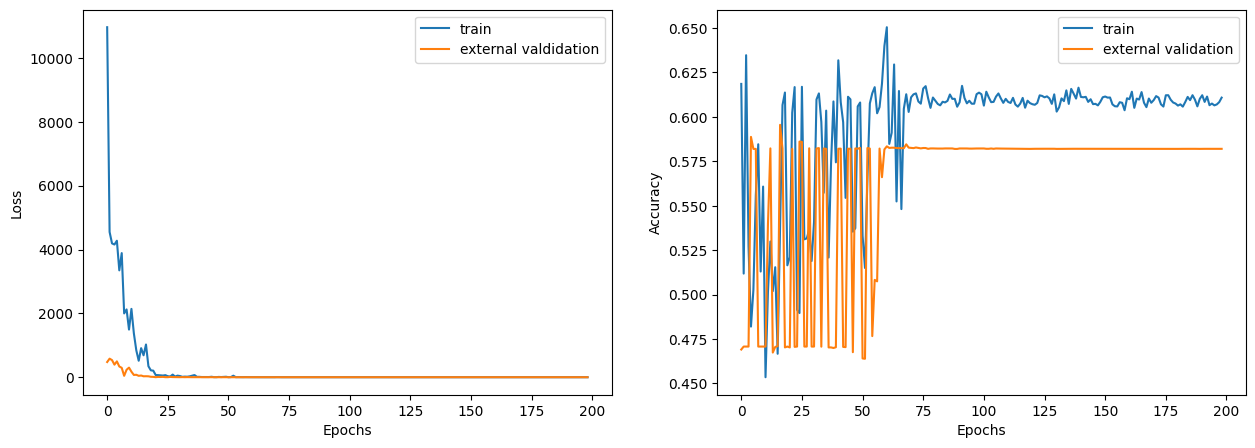

In [19]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(np.squeeze(np.matrix.tolist(resultsTrain[:,0])))
ax1.plot(np.squeeze(np.matrix.tolist(resultsVal[:,0])))
ax1.legend(["train", "external valdidation"], loc="upper right")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")

ax2.plot(np.squeeze(np.matrix.tolist(resultsTrain[:,1])))
ax2.plot(np.squeeze(np.matrix.tolist(resultsVal[:,1])))
ax2.legend(["train", "external validation"], loc="upper right")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
plt.show()

In [20]:
# PREDICCION

for _ in range(loader_test_Tati.steps_per_epoch):
    inputs,target = loader_test_Tati.__next__()
    y_prediction = model(inputs, training=False)
    y_prediction = np.argmax(y_prediction, axis = 1)
    y_test=np.argmax(target, axis=1)
    #Create confusion matrix and normalizes it over predicted (columns)
    result = tf.math.confusion_matrix(y_test, y_prediction, num_classes=2) 
    print(result)

tf.Tensor(
[[191771      0]
 [189618     61]], shape=(2, 2), dtype=int32)


In [21]:
# matriz_confusion = [[TP, FN],
#                     [FP, TN]]

TP = result[0,0].numpy()
FN = result[0,1].numpy()
FP = result[1,0].numpy()
TN = result[1,1].numpy()

accuracy = (TP+TN)/(TP+FP+FN+TN)
precision = TP/(TP+FP)
recall = TP/(TP+FN)
especificity = TN/(TN+FP)
f1 = (2*precision*recall)/(precision+recall)

print("accuracy (exactitud) = ", accuracy) # cantidad de predicciones positivas que fueron correctas
print("precision = ", precision) # proporcion de casos positivos detectados
print("recall = ", recall) # casos positivos que fueron correctamente identificadas por el algoritmo
print("especificity = ", especificity) # casos negativos que el algoritmo ha clasificado correctamente
print("f1 = ", f1)

accuracy (exactitud) =  0.5029020841525756
precision =  0.5028225774733933
recall =  1.0
especificity =  0.0003215959594894532
f1 =  0.6691709121362273


## SOBRE LA PREDICCIÓN

Para predecir hay que ejecutar `model(inputs,training=False)`, donde en un paso previo se define `inputs` como `inputs,target = loader_test.__next__()`.

Había intentado predecir con `model.predict(loader_test)`, pero esto NO REALIZA LA PREDICCIÓN. Probablemente se quedaba en un loop infinito o algo así, tratando de "desempaquetar" `loader_test`.

En el caso de las proteínas, al hacer `model.predict` lo corté en "653683/Unknown - 7336s 11ms/step", mientras que para CTU13 se quedaba sin memoria mucho antes, no pudiendo calcular ninguna predicción.


```
#Predict
y_prediction = model.predict(loader_test_Tati)
y_prediction = np.argmax(y_prediction, axis = 1)
y_test=np.argmax(dataset_test[0].y, axis=1)
#Create confusion matrix and normalizes it over predicted (columns)
result = confusion_matrix(y_test, y_prediction , normalize='pred')
print(result)
```

Incluso, pensando que era un problema de memoria, guardé el modelo y después quise forzar la predicción en la CPU al reiniciar el kernel, pero tampoco llegaba a buen puerto:

```
# Después de entrenar:
os.mkdir("/mnt/modelo")
model.save("/mnt/modelo/", include_optimizer=False)

# Reiniciar el kernel, cargar el modelo e intentar predecir (con la función equivocada...)
from tensorflow import keras
model = keras.models.load_model("/mnt/modelo/")

with tf.device('/cpu:0'):
    y_prediction = model.predict(loader_test_Tati)
    y_prediction = np.argmax(y_prediction, axis = 1)
```
